In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline
import seaborn as sns

In [4]:
X,y = make_blobs(n_samples=1000, centers=3, n_features=3)

In [5]:
X

array([[ 1.05267185,  6.98893631,  5.56020262],
       [ 3.00431873, -8.47203288, -8.95876086],
       [ 3.76536347, -6.62329728, -7.18321907],
       ...,
       [-4.03119657,  7.7381004 , -0.17230377],
       [ 5.639827  ,  8.08684246,  3.89844921],
       [ 4.13335628, -5.71347001, -7.48201777]], shape=(1000, 3))

In [6]:
y

array([2, 0, 0, 2, 2, 1, 2, 0, 0, 0, 0, 1, 0, 2, 1, 2, 1, 2, 2, 2, 2, 1,
       1, 1, 0, 2, 0, 2, 2, 0, 1, 0, 1, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 1,
       2, 2, 0, 1, 0, 2, 1, 2, 2, 0, 0, 0, 2, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 2, 2, 1, 1, 1, 2, 2,
       2, 1, 0, 0, 0, 1, 0, 2, 2, 1, 0, 2, 0, 2, 0, 0, 1, 2, 1, 1, 0, 1,
       2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 2, 1, 1, 2, 2, 1, 0, 1, 0, 1, 2, 2,
       2, 1, 2, 2, 2, 1, 1, 1, 1, 0, 2, 0, 1, 1, 0, 2, 0, 0, 0, 0, 1, 2,
       2, 0, 0, 2, 0, 2, 0, 0, 2, 2, 0, 1, 1, 0, 1, 1, 1, 2, 2, 2, 0, 0,
       1, 0, 0, 1, 1, 1, 2, 1, 2, 0, 0, 2, 1, 2, 2, 2, 2, 0, 2, 2, 0, 2,
       2, 1, 0, 2, 1, 2, 0, 0, 0, 2, 1, 0, 0, 2, 1, 0, 2, 2, 0, 2, 0, 1,
       2, 0, 0, 0, 2, 0, 1, 1, 0, 1, 1, 0, 0, 1, 2, 0, 1, 1, 0, 2, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 2, 1, 1, 1, 2, 2, 0, 1, 2, 2, 1, 2, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 2, 1, 0, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1, 2,
       1, 2, 0, 0, 2, 2, 0, 1, 1, 1, 2, 0, 0, 0, 1,

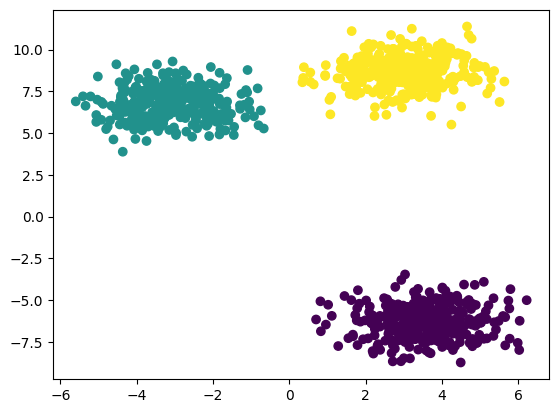

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [11]:
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [12]:
from sklearn.cluster import KMeans

In [13]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[2009.9999999999986,
 559.4007172358636,
 96.50301072147377,
 83.58122689265163,
 68.84762374098209,
 55.92182571209557,
 52.749458039174584,
 48.01613255363366,
 47.6335730662377,
 41.457876468787234]

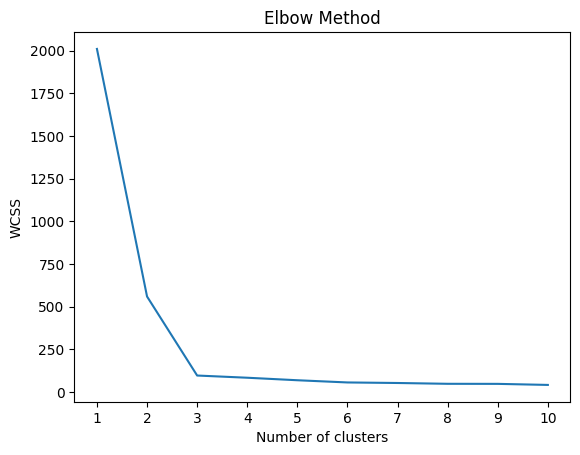

In [15]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3, init='k-means++')

In [17]:
kmeans.fit_predict(X_train_scaled)

array([1, 0, 0, 0, 2, 1, 2, 2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 1, 2, 0, 1,
       0, 2, 2, 2, 0, 2, 1, 0, 0, 1, 2, 1, 1, 2, 2, 1, 1, 0, 0, 1, 0, 2,
       2, 2, 0, 2, 1, 0, 1, 0, 1, 2, 2, 0, 2, 2, 1, 2, 1, 2, 1, 1, 2, 2,
       0, 0, 1, 0, 1, 0, 2, 0, 1, 0, 0, 0, 2, 2, 0, 0, 0, 1, 2, 2, 1, 2,
       2, 1, 2, 1, 1, 0, 0, 0, 0, 1, 1, 2, 2, 0, 0, 0, 2, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 0, 0, 1,
       1, 1, 2, 0, 2, 0, 0, 0, 1, 1, 2, 0, 0, 1, 2, 0, 0, 2, 0, 1, 0, 1,
       2, 0, 2, 2, 1, 0, 2, 2, 0, 1, 2, 1, 2, 2, 0, 0, 2, 1, 2, 2, 0, 1,
       2, 2, 0, 2, 2, 2, 0, 2, 2, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 2, 2,
       0, 0, 0, 1, 0, 0, 1, 0, 2, 2, 0, 1, 0, 1, 0, 2, 2, 0, 0, 1, 2, 1,
       1, 2, 2, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 2, 0, 0, 0, 1, 0, 0, 1, 2,
       1, 0, 0, 2, 2, 1, 1, 0, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 0, 1, 2, 2,
       0, 2, 2, 0, 1, 0, 2, 0, 1, 1, 2, 0, 2, 2, 2, 1, 0, 0, 1, 1, 1, 2,
       2, 1, 0, 2, 0, 2, 1, 2, 0, 2, 1, 1, 2, 0, 2,

In [18]:
y_pred = kmeans.predict(X_test_scaled)

In [19]:
y_pred

array([2, 2, 1, 2, 2, 0, 0, 2, 2, 2, 1, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1,
       2, 2, 1, 1, 2, 0, 1, 1, 0, 0, 1, 1, 0, 2, 2, 1, 0, 1, 0, 2, 0, 0,
       1, 1, 2, 0, 1, 1, 2, 2, 0, 2, 0, 0, 0, 1, 1, 2, 2, 1, 2, 1, 2, 1,
       1, 0, 2, 0, 0, 1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 0, 2, 2, 1, 2, 1,
       1, 0, 1, 2, 0, 1, 2, 0, 0, 2, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       2, 1, 2, 0, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 2, 2, 2, 0, 2, 0, 1, 2, 2, 1, 1, 1, 0, 2, 1, 1, 2, 2,
       1, 1, 0, 0, 0, 2, 0, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1,
       2, 0, 1, 0, 0, 2, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 2, 0, 1, 0, 1, 0,
       1, 2, 1, 1, 2, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 0, 1, 2, 2, 1,
       2, 1, 1, 2, 0, 1, 1, 2, 2, 0, 0, 2, 2, 2, 2, 1, 1, 2, 2, 0, 2, 1,
       1, 1, 2, 0, 1, 2, 0, 0, 2, 2, 2, 0, 2, 2, 1, 0, 2, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 2, 2, 0, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 1, 1,

In [20]:
!pip install kneed


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [21]:
from kneed import KneeLocator

In [22]:
k1 = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')

In [23]:
k1.elbow

np.int64(3)

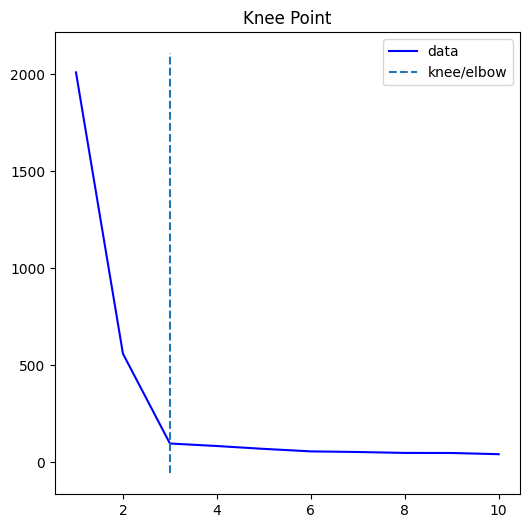

In [24]:
k1.plot_knee()

In [25]:
## Silhoutte Score
from sklearn.metrics import silhouette_score

In [26]:
silhouette_coefficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)

In [27]:
silhouette_coefficients

[0.6945229290160027,
 0.7892721884977577,
 0.6447464311163694,
 0.46142703368472343,
 0.4291254683759354,
 0.31069410448041823,
 0.2878459200091751,
 0.28933164576296216,
 0.2662878873854327]

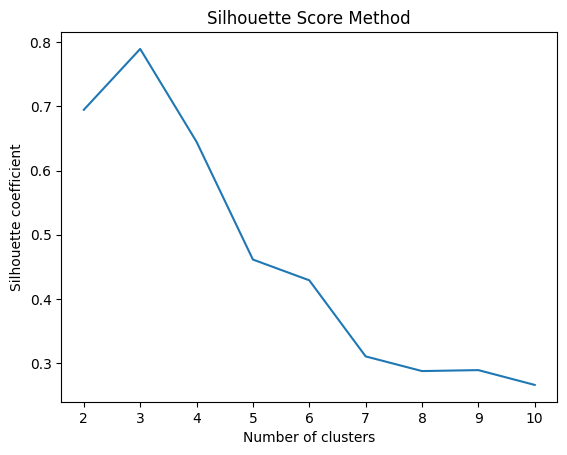

In [28]:
## Plotting the silhouette scores
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette coefficient')
plt.title('Silhouette Score Method')
plt.show()

## Devoloping a model for the clustering Algorithm


In [29]:
df = pd.read_csv('wine-clustering.csv')

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [32]:
df.columns

Index(['Alcohol', 'Malic_Acid', 'Ash', 'Ash_Alcanity', 'Magnesium',
       'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols',
       'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD280', 'Proline'],
      dtype='object')

In [33]:
print("Shape:", df.shape)
print("\nInfo:")
print(df.info())


Shape: (178, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB
None


In [34]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [35]:
# Quick statistical summary
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


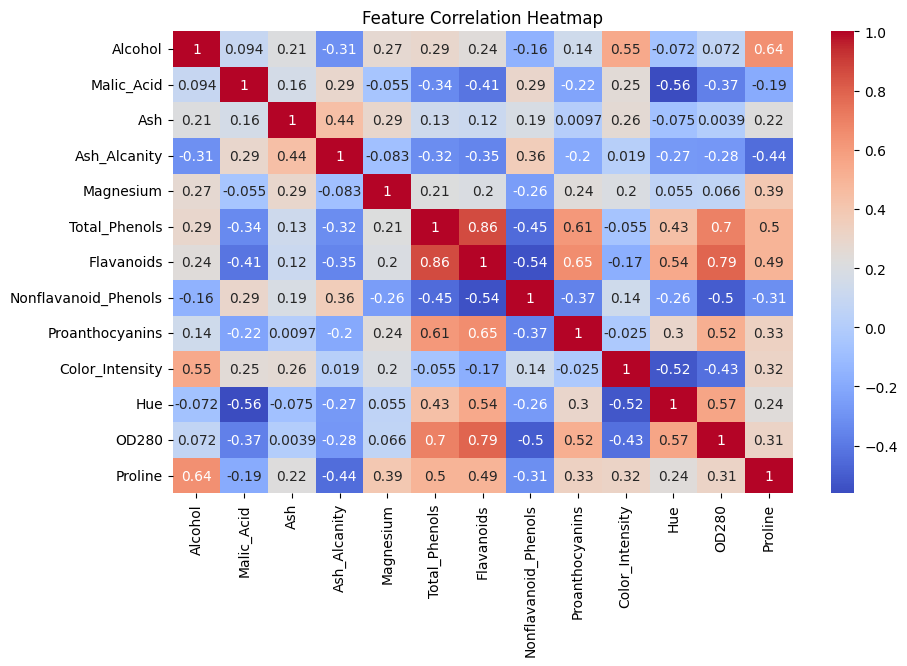

In [36]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

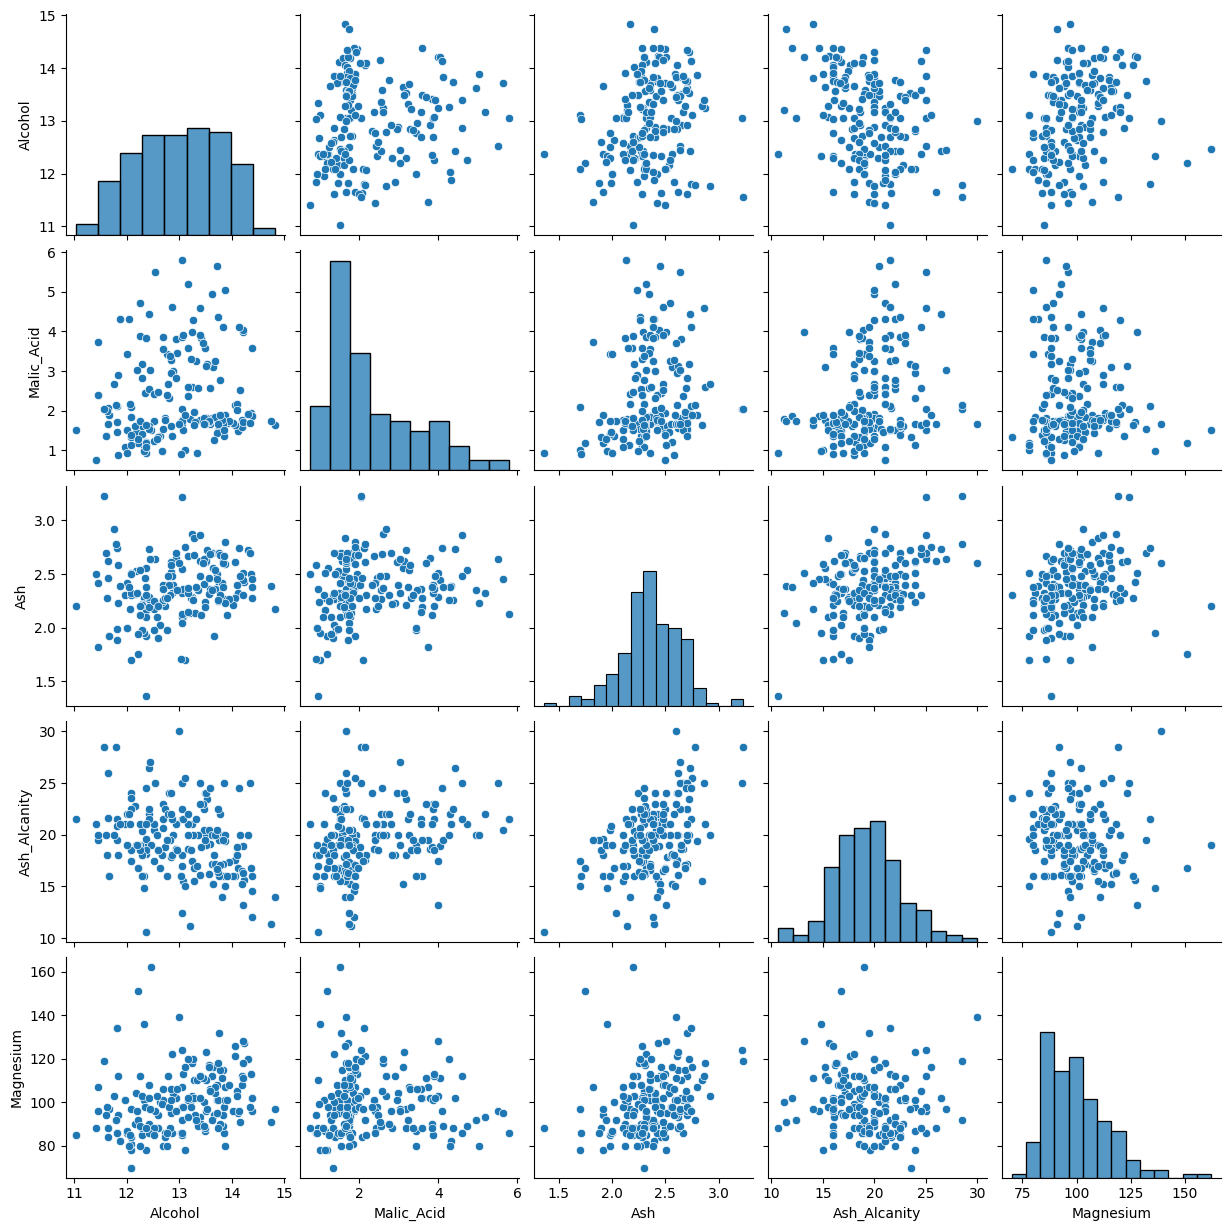

In [37]:
# Pairplot (sample for first 5 features to avoid heavy plot)
sns.pairplot(df.iloc[:, :5])
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(df)

In [39]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

In [40]:
# Store results
models = {}
scores = {}

# 1. KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
scores['KMeans'] = silhouette_score(X, kmeans_labels)
models['KMeans'] = kmeans

# 2. Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X)
scores['Agglomerative'] = silhouette_score(X, agg_labels)
models['Agglomerative'] = agg

# 3. Gaussian Mixture
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X)
scores['GMM'] = silhouette_score(X, gmm_labels)
models['GMM'] = gmm

# Print all scores
print("Silhouette Scores:", scores)

# Find best model
best_model = max(scores, key=scores.get)
print("\nBest Model:", best_model, "with score:", scores[best_model])

Silhouette Scores: {'KMeans': 0.2848589191898987, 'Agglomerative': 0.2774439826952265, 'GMM': 0.2848589191898987}

Best Model: KMeans with score: 0.2848589191898987


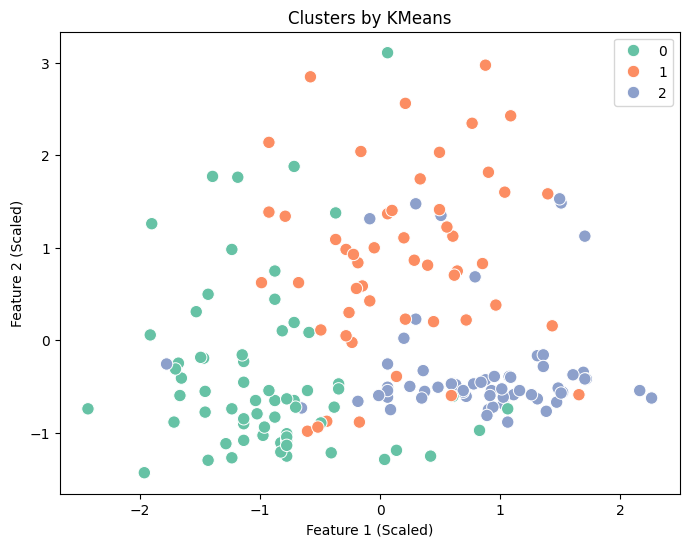

In [41]:
# Get best model labels
if best_model == 'KMeans':
    labels = kmeans_labels
elif best_model == 'Agglomerative':
    labels = agg_labels
else:
    labels = gmm_labels

# Add labels to dataframe
df['Cluster'] = labels

# Plot first 2 features for visualization
plt.figure(figsize=(8,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set2', s=80)
plt.title(f"Clusters by {best_model}")
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.show()

## Practice on new dataset

In [42]:
df1 = pd.read_csv('Live (1).csv')

In [43]:
df1.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [44]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [45]:
df1.columns

Index(['status_id', 'status_type', 'status_published', 'num_reactions',
       'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows',
       'num_hahas', 'num_sads', 'num_angrys', 'Column1', 'Column2', 'Column3',
       'Column4'],
      dtype='object')

In [46]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.983146
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.846893
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [47]:
df1.isnull().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

In [48]:
df1 = df1.drop(['Column1','Column2','Column3', 'Column4'],axis = 1 )

In [49]:
df1

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [50]:
df1['status_published'] = pd.to_datetime(df1['status_published'])

In [51]:
df1['status_type'].unique()

array(['video', 'photo', 'link', 'status'], dtype=object)

In [52]:
df2 = df1.copy()

In [53]:
df1 = df1.drop(['status_id','status_published'], axis = 1)

In [54]:
df1.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


In [56]:
## Handling the categorical variable 'status_type'
df1 = pd.get_dummies(df1, columns=['status_type'], drop_first=True)

In [57]:
df1.head()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,status_type_photo,status_type_status,status_type_video
0,529,512,262,432,92,3,1,1,0,False,False,True
1,150,0,0,150,0,0,0,0,0,True,False,False
2,227,236,57,204,21,1,1,0,0,False,False,True
3,111,0,0,111,0,0,0,0,0,True,False,False
4,213,0,0,204,9,0,0,0,0,True,False,False


In [58]:
X = df1.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [59]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=50, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

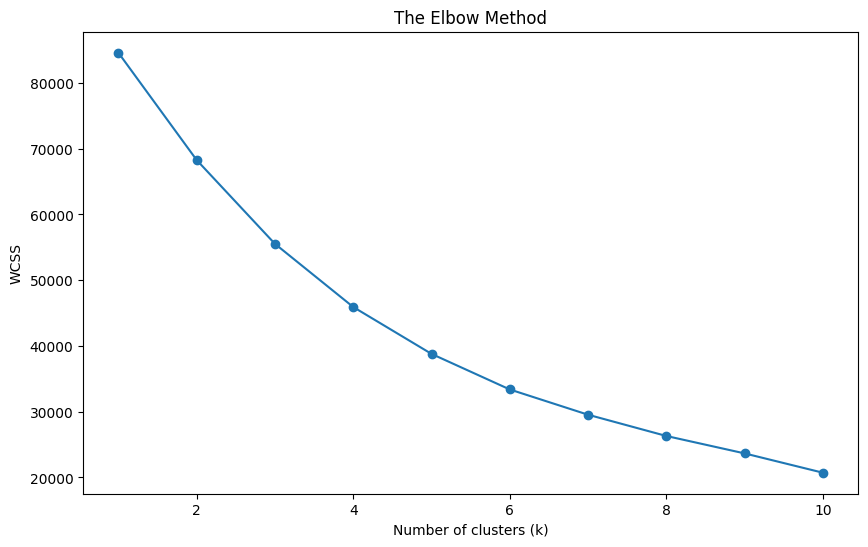

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

In [61]:
k1 = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')

In [62]:
k1.elbow

np.int64(5)

In [63]:
optimal_k = 5
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_model.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


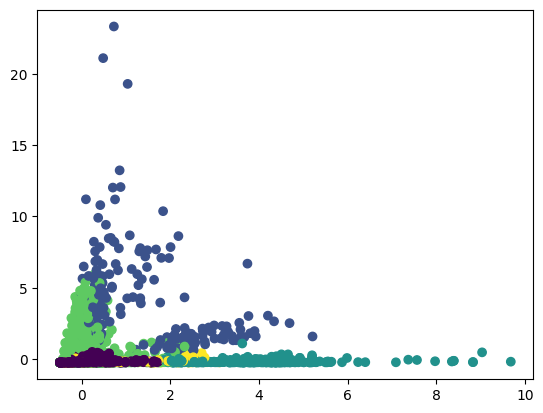

In [64]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_model.labels_, cmap='viridis')

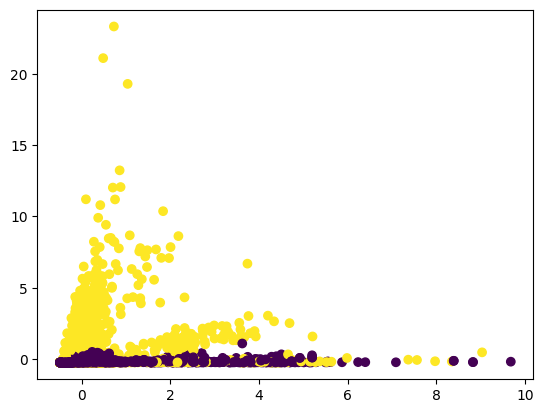

In [65]:
## According to the shilhouette score, 2 clusters is optimal

optimal_k= 2
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, max_iter=300, random_state=42)
kmeans_model.fit(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_model.labels_, cmap='viridis')

In [66]:
df2['total_engagement'] = (df2['num_reactions'] + 
                              df2['num_comments'] + 
                              df2['num_shares'])

In [67]:
df2['engagement_rate'] = df2['total_engagement'] / df2['num_reactions'].replace(0, 1)

In [68]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   status_id         7050 non-null   object        
 1   status_type       7050 non-null   object        
 2   status_published  7050 non-null   datetime64[ns]
 3   num_reactions     7050 non-null   int64         
 4   num_comments      7050 non-null   int64         
 5   num_shares        7050 non-null   int64         
 6   num_likes         7050 non-null   int64         
 7   num_loves         7050 non-null   int64         
 8   num_wows          7050 non-null   int64         
 9   num_hahas         7050 non-null   int64         
 10  num_sads          7050 non-null   int64         
 11  num_angrys        7050 non-null   int64         
 12  total_engagement  7050 non-null   int64         
 13  engagement_rate   7050 non-null   float64       
dtypes: datetime64[ns](1), fl

In [69]:
features_for_clustering = [
    'num_reactions', 'num_comments', 'num_shares', 
    'num_likes', 'num_loves', 'num_wows', 
    'num_hahas', 'num_sads', 'num_angrys',
    'total_engagement'
]

In [70]:
X = df2[features_for_clustering]

In [71]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


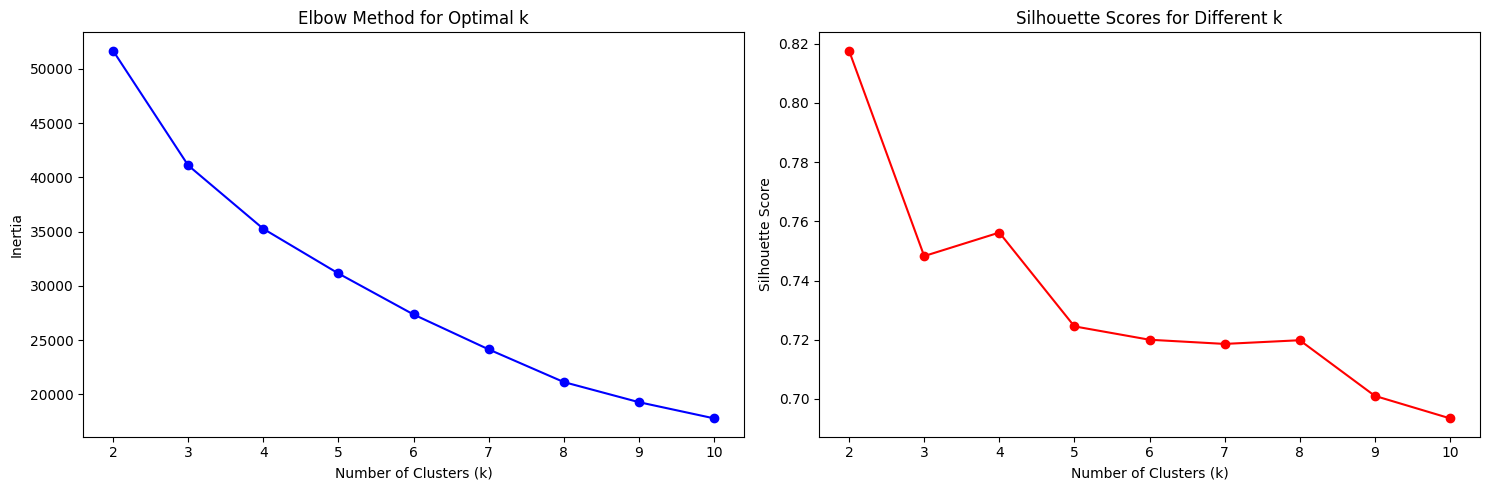

Optimal number of clusters based on silhouette score: 2


In [72]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
    if k > 1:  # Silhouette score requires at least 2 clusters
        silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, inertia, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')

# Silhouette scores
ax2.plot(range(2, 11), silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores for Different k')

plt.tight_layout()
plt.show()

# Find optimal k based on silhouette score
optimal_k = range(2, 11)[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")

In [73]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df2['cluster'] = clusters

silhouette_avg = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {silhouette_avg:.3f}")

cluster_summary = df2.groupby('cluster').agg({
    'num_reactions': 'mean',
    'num_comments': 'mean', 
    'num_shares': 'mean',
    'total_engagement': 'mean',
    'status_type': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Mixed',
    'status_id': 'count'
}).rename(columns={'status_id': 'count'})

print("\nCluster Summary:")
print(cluster_summary)

Silhouette Score: 0.818

Cluster Summary:
         num_reactions  num_comments  num_shares  total_engagement  \
cluster                                                              
0           203.836291     96.398107   20.827418        321.061816   
1           847.170139   3228.701389  490.708333       4566.579861   

        status_type  count  
cluster                     
0             photo   6762  
1             video    288  


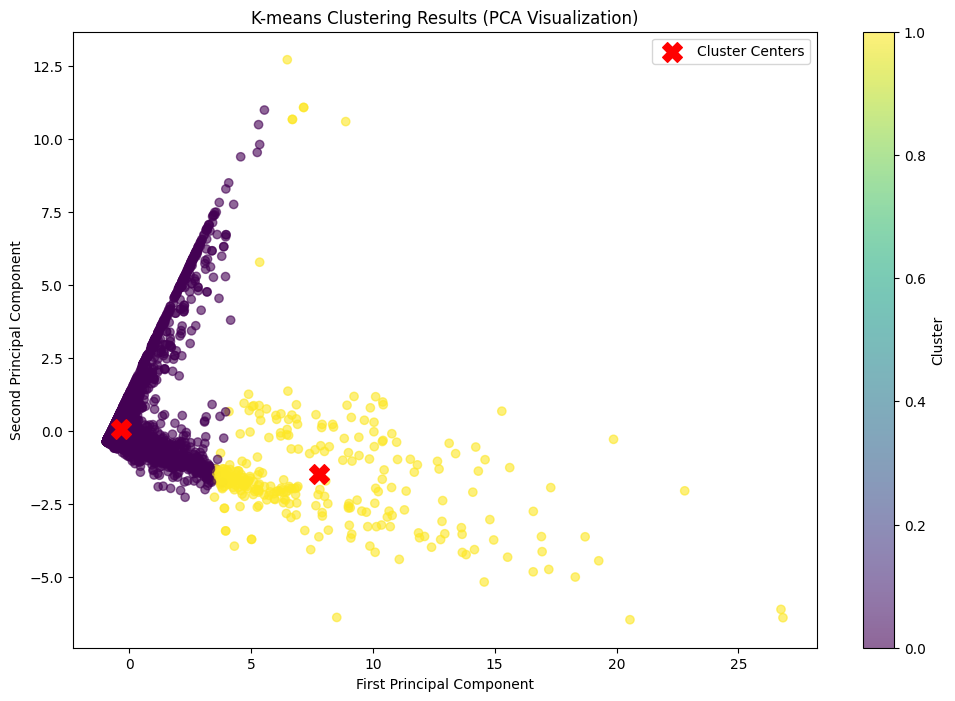

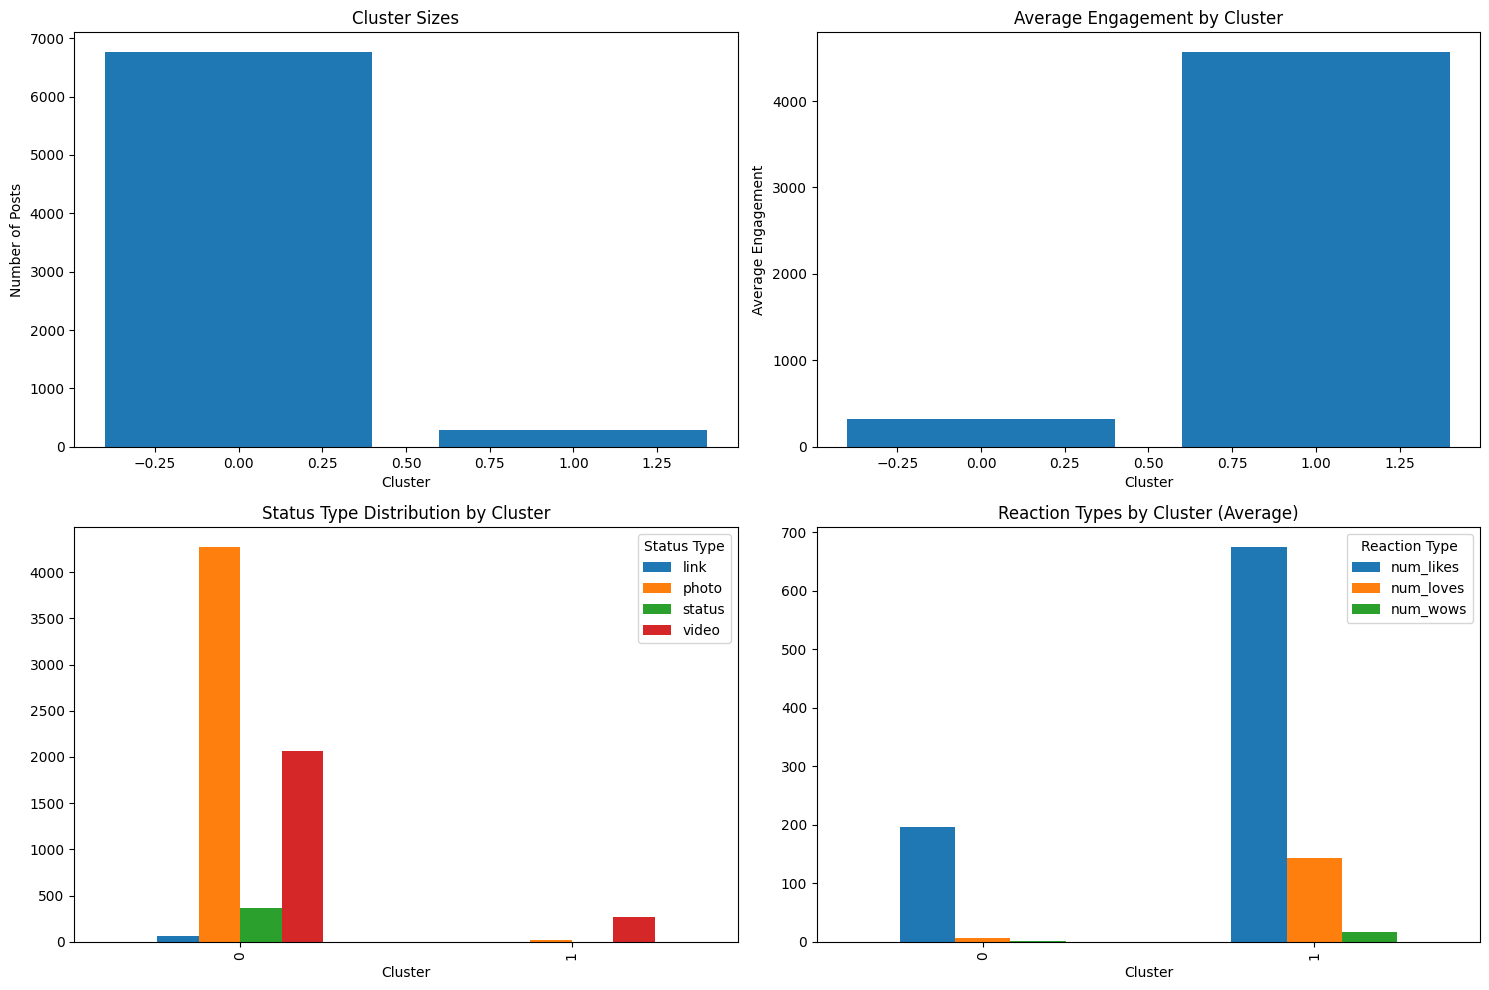

In [74]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-means Clustering Results (PCA Visualization)')

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Cluster Centers')
plt.legend()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

cluster_sizes = df2['cluster'].value_counts().sort_index()
axes[0,0].bar(cluster_sizes.index, cluster_sizes.values)
axes[0,0].set_title('Cluster Sizes')
axes[0,0].set_xlabel('Cluster')
axes[0,0].set_ylabel('Number of Posts')

engagement_by_cluster = df2.groupby('cluster')['total_engagement'].mean()
axes[0,1].bar(engagement_by_cluster.index, engagement_by_cluster.values)
axes[0,1].set_title('Average Engagement by Cluster')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Average Engagement')

cluster_status = pd.crosstab(df2['cluster'], df2['status_type'])
cluster_status.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Status Type Distribution by Cluster')
axes[1,0].set_xlabel('Cluster')
axes[1,0].legend(title='Status Type')

reaction_by_cluster = df2.groupby('cluster')[['num_likes', 'num_loves', 'num_wows']].mean()
reaction_by_cluster.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Reaction Types by Cluster (Average)')
axes[1,1].set_xlabel('Cluster')
axes[1,1].legend(title='Reaction Type')

plt.tight_layout()
plt.show()

In [75]:

print("CLUSTER PROFILES:")
print("="*50)

for cluster_id in range(optimal_k):
    cluster_data = df2[df2['cluster'] == cluster_id]
    
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(f"  - Most common status type: {cluster_data['status_type'].mode().iloc[0]}")
    print(f"  - Average engagement: {cluster_data['total_engagement'].mean():.1f}")
    print(f"  - Average reactions: {cluster_data['num_reactions'].mean():.1f}")
    print(f"  - Average comments: {cluster_data['num_comments'].mean():.1f}")
    print(f"  - Average shares: {cluster_data['num_shares'].mean():.1f}")
    
   
    reaction_cols = ['num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
    avg_reactions = cluster_data[reaction_cols].mean()
    dominant_reaction = avg_reactions.idxmax().replace('num_', '').title()
    print(f"  - Dominant reaction: {dominant_reaction} ({avg_reactions.max():.1f} avg)")


print("\n" + "="*50)
print("BUSINESS INSIGHTS:")
print("="*50)


high_engagement_clusters = cluster_summary.nlargest(2, 'total_engagement').index.tolist()
print(f"\nHigh-engagement clusters: {high_engagement_clusters}")

for cluster_id in high_engagement_clusters:
    cluster_info = cluster_summary.loc[cluster_id]
    print(f"Cluster {cluster_id}: {cluster_info['status_type']} posts with {cluster_info['total_engagement']:.1f} avg engagement")


low_engagement_clusters = cluster_summary.nsmallest(2, 'total_engagement').index.tolist()
print(f"\nLow-engagement clusters: {low_engagement_clusters}")


print("\nRECOMMENDATIONS:")
print("1. Focus on creating more content similar to high-engagement clusters")
print("2. Analyze what makes high-performing clusters successful")
print("3. Consider adjusting strategy for low-engagement clusters")
print("4. Use cluster insights to tailor content to different audience segments")

CLUSTER PROFILES:

Cluster 0 (n=6762):
  - Most common status type: photo
  - Average engagement: 321.1
  - Average reactions: 203.8
  - Average comments: 96.4
  - Average shares: 20.8
  - Dominant reaction: Likes (195.5 avg)

Cluster 1 (n=288):
  - Most common status type: video
  - Average engagement: 4566.6
  - Average reactions: 847.2
  - Average comments: 3228.7
  - Average shares: 490.7
  - Dominant reaction: Likes (674.3 avg)

BUSINESS INSIGHTS:

High-engagement clusters: [1, 0]
Cluster 1: video posts with 4566.6 avg engagement
Cluster 0: photo posts with 321.1 avg engagement

Low-engagement clusters: [0, 1]

RECOMMENDATIONS:
1. Focus on creating more content similar to high-engagement clusters
2. Analyze what makes high-performing clusters successful
3. Consider adjusting strategy for low-engagement clusters
4. Use cluster insights to tailor content to different audience segments
